In [1]:
# %pip install bt pandas numpy matplotlib polars mlforecast

In [2]:
# %pip install hyperopt

In [3]:
# %pip install numpy==1.25.2 pandas==2.0.3 gym_mtsim

In [4]:
import numpy as np
print(np.__version__)
import pandas as pd
print(pd.__version__)

1.25.2
2.0.3


In [5]:
import pandas as pd
import numpy as np
import polars as pl
import pickle
import sys
sys.path.append("C:/Users/WilliamFetzner/Documents/Trading/")
from gym_mtsim_forked.gym_mtsim.data import FOREX_DATA_PATH, FOREX_DATA_PATH_15MIN
import pytz
from datetime import datetime, timedelta, time
from gym_mtsim import MtSimulator, OrderType, Order, OrderNotFound
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials, STATUS_FAIL
from typing import Dict

c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment forex-hedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment forex-unhedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment stocks-hedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\i

In [6]:
path_to_trading_folder = 'C:/Users/WilliamFetzner/Documents/Trading/'
# data_path = 'EURUSD_full_tickstory_data_15_min.csv'
data_path = 'EURUSD_full_tickstory_data_hourly.csv'

In [7]:
with open(FOREX_DATA_PATH_15MIN, 'rb') as f:
    symbols_1hr = pickle.load(f)
# convert symbols_1hr to a pd.dataframe
symbols_1hr[1]['EURUSD'].index = pd.to_datetime(symbols_1hr[1]['EURUSD'].index)
full_data = symbols_1hr[1]['EURUSD']
full_data.columns = full_data.columns.str.lower()
full_data

,open,high,low,close
Time,,,,
2016-08-01 03:00:00+00:00,1.11672,1.11750,1.11660,1.11750
2016-08-01 03:15:00+00:00,1.11749,1.11767,1.11692,1.11701
2016-08-01 03:30:00+00:00,1.11701,1.11740,1.11670,1.11732
2016-08-01 03:45:00+00:00,1.11732,1.11761,1.11694,1.11750
2016-08-01 04:00:00+00:00,1.11750,1.11782,1.11728,1.11729
...,...,...,...,...
2024-08-09 22:45:00+00:00,1.09183,1.09189,1.09179,1.09187
2024-08-09 23:00:00+00:00,1.09186,1.09194,1.09167,1.09168
2024-08-09 23:15:00+00:00,1.09168,1.09179,1.09167,1.09175


# Strategy Class

In [8]:
class ADXSuperTrendStrategy:
    def __init__(
        self,
        bb_period: int = 20,
        bb_std: float = 2.0,
        keltner_period: int = 20,
        keltner_atr_multiplier: float = 1.5,
        rsi_period: int = 14,
        stoch_period: int = 14,
        stoch_smoothk: int = 3,
        stoch_smoothd: int = 3,
        roc_period: int = 10,
        vol_lookback: int = 100, 
        high_timeframe: str ='4H',
        adx_length: int = 14,
        adx_di: int = 14,
        sma_window: int = 50,
        trend_window: int = 5,
        stop_loss_mult: float = 1.5,
        take_profit_mult: float = 1.5,
    ):
        self.bb_period = bb_period
        self.bb_std = bb_std
        self.keltner_period = keltner_period
        self.keltner_atr_multiplier = keltner_atr_multiplier
        self.rsi_period = rsi_period
        self.stoch_period = stoch_period
        self.stoch_smoothk = stoch_smoothk
        self.stoch_smoothd = stoch_smoothd
        self.roc_period = roc_period
        self.vol_lookback = vol_lookback
        self.high_timeframe = high_timeframe
        self.adx_length = adx_length
        self.adx_di = adx_di
        self.sma_window = sma_window
        self.trend_window = trend_window
        self.stop_loss_mult = stop_loss_mult
        self.take_profit_mult = take_profit_mult

    def calculate_bollinger_bands(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate Bollinger Bands"""
        df['bb_middle'] = df['close'].rolling(window=self.bb_period).mean()
        std = df['close'].rolling(window=self.bb_period).std()
        df['bb_upper'] = df['bb_middle'] + (std * self.bb_std)
        df['bb_lower'] = df['bb_middle'] - (std * self.bb_std)
        df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_middle']
        return df

    def calculate_keltner_channels(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate Keltner Channels"""
        typical_price = (df['high'] + df['low'] + df['close']) / 3
        df['kc_middle'] = typical_price.rolling(window=self.keltner_period).mean()
        
        # Calculate ATR
        high_low = df['high'] - df['low']
        high_close = np.abs(df['high'] - df['close'].shift())
        low_close = np.abs(df['low'] - df['close'].shift())
        ranges = pd.concat([high_low, high_close, low_close], axis=1)
        true_range = ranges.max(axis=1)
        atr = true_range.rolling(window=self.keltner_period).mean()
        
        df['kc_upper'] = df['kc_middle'] + (atr * self.keltner_atr_multiplier)
        df['kc_lower'] = df['kc_middle'] - (atr * self.keltner_atr_multiplier)
        return df

    def calculate_rsi(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate RSI"""
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=self.rsi_period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=self.rsi_period).mean()
        rs = gain / loss
        df['rsi'] = 100 - (100 / (1 + rs))
        return df

    def calculate_stochastic(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate Stochastic Oscillator"""
        low_min = df['low'].rolling(window=self.stoch_period).min()
        high_max = df['high'].rolling(window=self.stoch_period).max()
        
        k_fast = 100 * (df['close'] - low_min) / (high_max - low_min)
        df['stoch_k'] = k_fast.rolling(window=self.stoch_smoothk).mean()
        df['stoch_d'] = df['stoch_k'].rolling(window=self.stoch_smoothd).mean()
        return df

    def calculate_roc(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate Rate of Change"""
        df['roc'] = ((df['close'] - df['close'].shift(self.roc_period)) / 
                     df['close'].shift(self.roc_period)) * 100
        return df

    def calculate_volatility_state(self, df: pd.DataFrame) -> pd.DataFrame:
        """Determine if we're in high or low volatility state"""
        df['volatility'] = df['close'].rolling(window=20).std()
        df['vol_ma'] = df['volatility'].rolling(window=self.vol_lookback).mean()
        df['high_volatility'] = df['volatility'] > df['vol_ma']
        return df

    def check_squeeze(self, df: pd.DataFrame) -> pd.DataFrame:
        """Check if price is in a squeeze (Bollinger Bands inside Keltner Channels)"""
        df['squeeze'] = (df['bb_upper'] <= df['kc_upper']) & (df['bb_lower'] >= df['kc_lower'])
        return df
    
    def count_consecutive_signals(self, df):
        # Initialize consecutive_bars column with 0
        df['consecutive_bars'] = 0
        
        # Start from second row (index 1)
        for i in range(1, len(df)):
            if df['signal'].iloc[i] == df['signal'].iloc[i-1]:
                # If signal is same as previous, increment previous count
                df.loc[df.index[i], 'consecutive_bars'] = df['consecutive_bars'].iloc[i-1] + 1
        
        return df
    
    def calculate_ohlc4(self, df: pd.DataFrame):
        df['ohlc4'] = (df['open'] + df['high'] + df['low'] + df['close']) / 4
        return df
    
    def calculate_sma(self, df: pd.DataFrame, window: int = 50) -> pd.DataFrame:
        """Calculate Simple Moving Average"""
        if 'ohlc4' not in df.columns:
            df = self.calculate_ohlc4(df)
        df['sma'] = df['ohlc4'].rolling(window=window).mean()
        return df
    
    def calculate_trend(self, df: pd.DataFrame, trend_window: int = 5) -> pd.DataFrame:
        """Determine if the trend is up or down"""
        if 'sma' not in df.columns:
            df = self.calculate_sma(df, self.sma_window)
        # find the lowest close and lowest open in the last {trend_window} rows
        df['lowest_close'] = df['close'].rolling(window=trend_window).min()
        df['lowest_open'] = df['open'].rolling(window=trend_window).min()
        # find the highest close and highest open in the last {trend_window} rows
        df['highest_open'] = df['open'].rolling(window=trend_window).max()
        df['highest_close'] = df['close'].rolling(window=trend_window).max()
        df['trend'] = np.where(
            # if both the lowest close and lowest open are greater than the sma than the trend is up
            ((df['lowest_close'] > df['sma']) & (df['lowest_open'] > df['sma']) &
             (df['highest_close'] > df['sma']) & (df['highest_open'] > df['sma'])), 1,
            # if both the highest close and highest open are less than the sma than the trend is down
            np.where(
                ((df['highest_close'] < df['sma']) & (df['highest_open'] < df['sma']) &
                 (df['lowest_close'] < df['sma']) & (df['lowest_open'] < df['sma'])), -1,
                 # otherwise it is ranging
                  0)
        )
        return df
    def calculate_adx(self, df, adx_len=14, di_len=14):
        """
        Calculate Average Directional Index (ADX)
        
        Parameters:
            df: DataFrame with 'high' and 'low' columns
            adx_len: ADX smoothing period
            di_len: DI length period
        """
        # Calculate directional movement
        high_change = df['high'].diff()
        low_change = -df['low'].diff()
        
        # Calculate +DM and -DM
        plus_dm = np.where((high_change > low_change) & (high_change > 0), high_change, 0)
        minus_dm = np.where((low_change > high_change) & (low_change > 0), low_change, 0)
        
        # Calculate True Range
        tr = pd.DataFrame()
        tr['h-l'] = df['high'] - df['low']
        tr['h-pc'] = abs(df['high'] - df['close'].shift(1))
        tr['l-pc'] = abs(df['low'] - df['close'].shift(1))
        tr = tr.max(axis=1)
        
        # Smooth TR and DM
        tr_smooth = tr.rolling(window=di_len).mean()
        plus_dm_smooth = pd.Series(plus_dm).rolling(window=di_len).mean()
        minus_dm_smooth = pd.Series(minus_dm).rolling(window=di_len).mean()
        
        # Calculate +DI and -DI
        plus_di = 100 * (plus_dm_smooth / tr_smooth)
        minus_di = 100 * (minus_dm_smooth / tr_smooth)
        
        # Calculate ADX
        dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di)
        adx = dx.rolling(window=adx_len).mean()

        return adx
    
    def generate_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        """Generate trading signals based on strategy rules"""
        # Initialize signal column
        df['signal'] = 0
        # Long signal conditions
        long_conditions = (
            (df['trend'] == 1) & # SMA trend confirms
            (df['adx_slope'] > 0)  # ADX slope confirms
        )
        # Short signal conditions
        short_conditions = (
            (df['trend'] == -1) & # SMA trend confirms
            (df['adx_slope'] > 0)  # ADX slope confirms
        )
        
        # Set signals
        df.loc[long_conditions, 'signal'] = 1
        df.loc[short_conditions, 'signal'] = -1
        
        return df

    def calculate_position_size(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate position size based on ATR"""
        # Calculate ATR-based position sizing
        df['atr'] = df['high'].rolling(window=14).max() - df['low'].rolling(window=14).min()
        df['position_size'] = 1.0  # Base position size
        
        # Adjust for volatility
        # df.loc[df['high_volatility'], 'position_size'] *= 0.5
        
        return df
    
    
    def apply_strategy(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply the complete strategy to the dataframe"""

        df_reindexed = df.set_index('Time')

        # add in whether or not the higher timeframe was trending in the same direction
        df_high = df_reindexed.resample(self.high_timeframe).agg({
            'open': 'first', 
            'high': 'max', 
            'low': 'min', 
            'close': 'last'
        }).dropna()

        df_high = self.calculate_trend(df_high, self.trend_window)
        # print(f"there are {len(df_high[df_high['trend'] == 1])} bullish supertrend direction rows")
        # print(f"there are {len(df_high[df_high['trend'] == -1])} bearish supertrend direction rows")
        df_high = df_high.reset_index()
        df_high['Time'] = pd.to_datetime(df_high['Time'])
        adx_values = self.calculate_adx(df_high, self.adx_length, self.adx_di)
        adx_df = pd.DataFrame(adx_values, columns=['adx'])
        
        df_high = df_high.merge(adx_df, left_index=True, right_index=True, how='left')
        
        # calculate the slope of the adx
        df_high['adx_slope'] = df_high['adx'].diff()
        # print(df_high.info())
        # merge back with df
        df_high['Time_prev'] = df_high['Time'] + pd.Timedelta(hours=4)
        high_cols = [col for col in df_high.columns if col not in df.columns]
        
        df = df.merge(df_high[[*high_cols]], left_on='Time', right_on='Time_prev', how='left')
        df[[*high_cols]] = df[[*high_cols]].ffill()
    
        # Generate signals and position sizes
        df = self.generate_signals(df)
        df = self.calculate_position_size(df)
        df = self.count_consecutive_signals(df)

               
        # Calculate stop levels
        df['stop_distance'] = df['atr'] * self.stop_loss_mult  # Use 1.5 * ATR for stop distance - 0.0025 
        df['profit_distance'] = df['atr'] * self.take_profit_mult #0.005 #
        df['stop_level'] = np.where(
            df['signal'] == 1,
            df['close'] - df['stop_distance'],
            np.where(
                df['signal'] == -1,
                df['close'] + df['stop_distance'],
                np.nan
            )
        )
        
        return df

    def get_trade_info(self, df: pd.DataFrame, index: int) -> Dict:
        """Get trade information for a specific signal"""
        row = df.iloc[index]
        return {
            'signal': row['signal'],
            'entry_price': row['close'],
            'stop_level': row['stop_level'],
            'position_size': row['position_size'],
            'volatility_state': 'high' if row['high_volatility'] else 'low',
            'squeeze_state': row['squeeze'],
            'rsi': row['rsi'],
            'stoch_k': row['stoch_k'],
            'roc': row['roc']
        }


In [9]:
strategy = ADXSuperTrendStrategy(
    high_timeframe='4H',
    trend_window=5,
    sma_window=50,
    adx_length=14,
    adx_di=14
)


# add in whether or not the higher timeframe was trending in the same direction
df_high = full_data.resample(strategy.high_timeframe).agg({
    'open': 'first', 
    'high': 'max', 
    'low': 'min', 
    'close': 'last'
}).dropna()

df_high = strategy.calculate_trend(df_high, strategy.trend_window)
df_high['trend'].value_counts(dropna=False)

trend
-1    4762
 1    4684
 0    3081
Name: count, dtype: int64

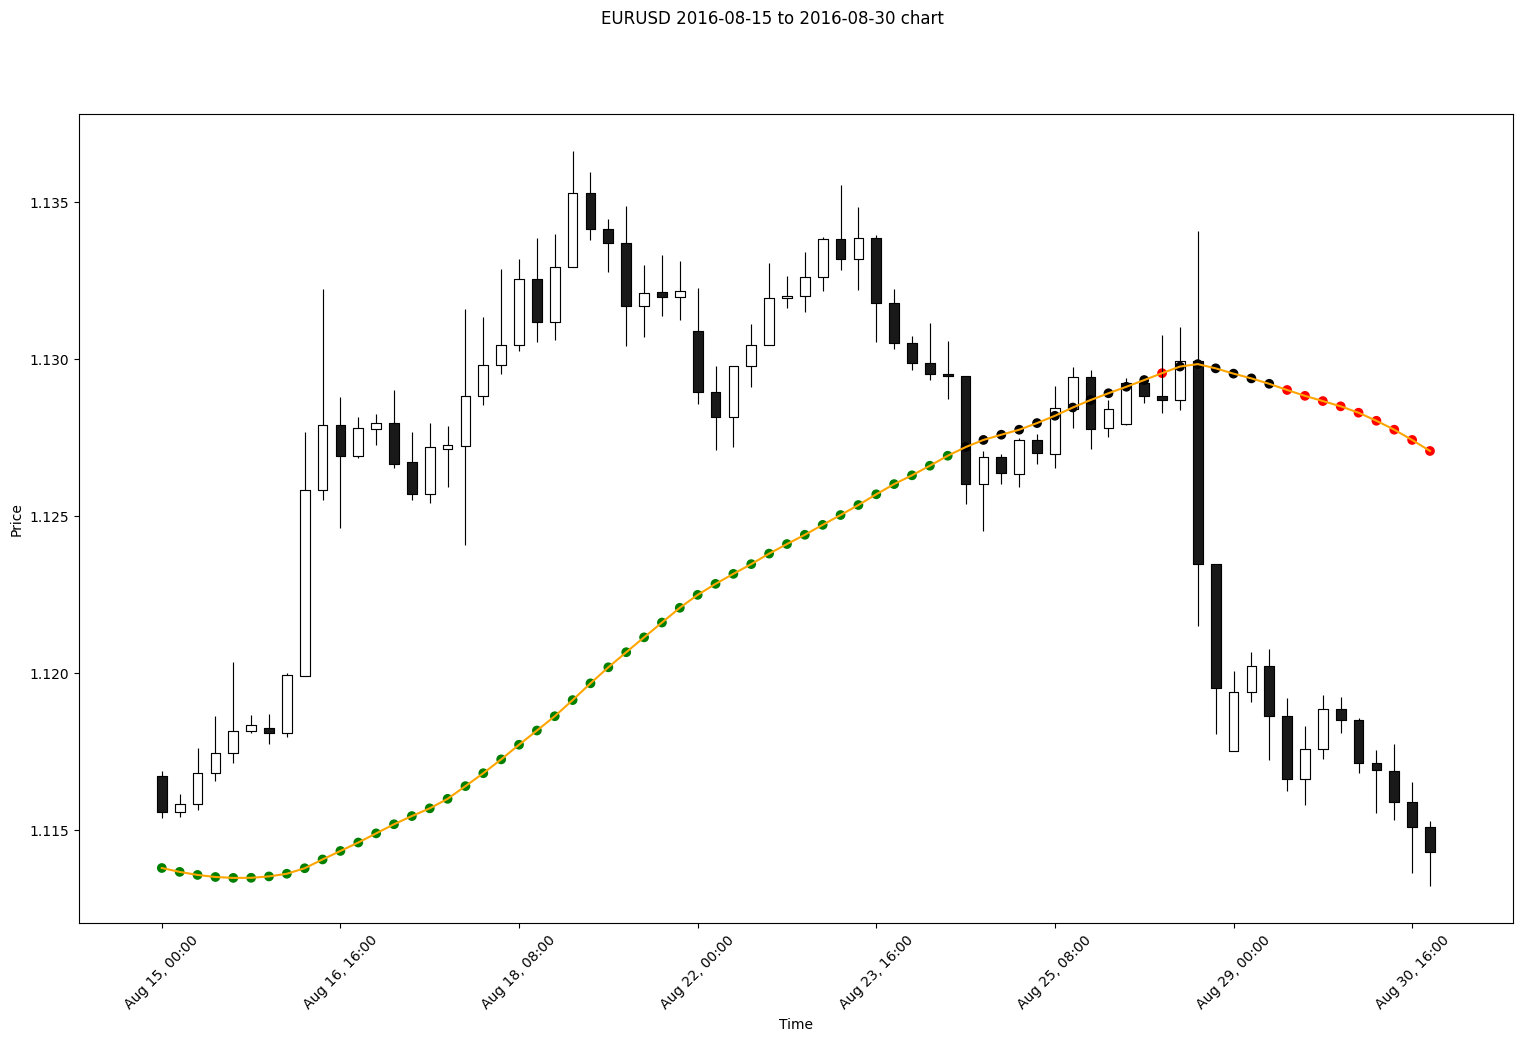

In [10]:
import matplotlib.pyplot as plt
import mplfinance
# filter to where the date and time is between 2024-03-07 16:36:00 and 2024.03.08 12:30:00
df_high_idx_rst = df_high.reset_index()
df_high_idx_rst['Time'] = pd.to_datetime(df_high_idx_rst['Time'])
df_high_select_day = df_high_idx_rst[
    (df_high_idx_rst['Time'].dt.date >= datetime(2016, 8, 15).date()) & 
    (df_high_idx_rst['Time'].dt.date <= datetime(2016, 8, 30).date())
].set_index('Time')



fig, ax = plt.subplots()
mplfinance.plot(df_high_select_day, type='candle', ax=ax, volume=False, show_nontrading=False)
df_high_select_day_reset = df_high_select_day.reset_index()
df_high_select_day_reset['Time'] = pd.to_datetime(df_high_select_day_reset['Time'])

# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
ax.plot(df_high_select_day_reset.index, df_high_select_day_reset['sma'], color='orange', label='SMA')
# Create color mapping
color_map = {1: 'green', 0: 'black', -1: 'red'}
colors = df_high_select_day_reset['trend'].map(color_map)

# Plot with mapped colors
ax.scatter(df_high_select_day_reset.index, df_high_select_day_reset['sma'], color=colors)

ax.set_xlabel('Time')
ax.set_ylabel('Price')
# find the date of the first and last index
first_date = df_high_select_day_reset['Time'].iloc[0]
last_date = df_high_select_day_reset['Time'].iloc[-1]
fig.suptitle(f'EURUSD {first_date.date()} to {last_date.date()} chart')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)

plt.show()

In [11]:
def find_seconds_to_next_news(df, news_counts):
    # Ensure both DataFrames have their time columns as datetime
    df['Time'] = pd.to_datetime(df['Time'])
    news_counts['datetime'] = pd.to_datetime(news_counts['datetime'])

    # Combine both DataFrames
    combined = pd.concat([
        df[['Time']].assign(source='main').rename(columns={'Time': 'time'}),
        news_counts[['datetime']].assign(source='news').rename(columns={'datetime': 'time'})
    ])

    # Sort by time and source
    combined = combined.sort_values(by=['time', 'source'], ascending=[True, False])

    # Find the next and previous news events
    result = combined.copy()
    result['prev_news_time'] = np.where(result['source'] == 'news', result['time'], None)
    result['next_news_time'] = np.where(result['source'] == 'news', result['time'], None)
    
    result['prev_news_time'] = result['prev_news_time'].ffill()
    result['next_news_time'] = result['next_news_time'].bfill()

    # Filter for main events and calculate time differences
    result = result[result['source'] == 'main'].copy()
    
    result['time_week_nbr'] = result['time'].dt.isocalendar().week
    result['prev_time_week_nbr'] = result['prev_news_time'].dt.isocalendar().week
    result['next_time_week_nbr'] = result['next_news_time'].dt.isocalendar().week

    # Calculate seconds since last news event
    result['seconds_since_last_news_event'] = np.where(
        result['time'].dt.isocalendar().week != result['prev_news_time'].dt.isocalendar().week,
        (result['prev_news_time'] - result['time']).dt.total_seconds() + (2 * 86400),
        (result['prev_news_time'] - result['time']).dt.total_seconds()
    )

    # Calculate seconds to next news event
    result['seconds_to_next_news_event'] = np.where(
        result['time'].dt.isocalendar().week != result['next_news_time'].dt.isocalendar().week,
        (result['next_news_time'] - result['time']).dt.total_seconds() - (2 * 86400),
        (result['next_news_time'] - result['time']).dt.total_seconds()
    )

    # Join back to original DataFrame
    final_df = df.merge(
        result[['time', 'seconds_since_last_news_event', 'seconds_to_next_news_event']],
        left_on='Time',
        right_on='time',
        how='left'
    ).drop(columns=['time'])

    return final_df


In [12]:
news_events_gr = pd.read_csv(
    f"{path_to_trading_folder}data_files/calendar_df_full_updated.csv", 
    parse_dates=['datetime']
).groupby('datetime').count()
news_events_gr.loc[:, 'event'] = (news_events_gr['Id'] >= 1).astype(int)
news_events_gr_id_drp = news_events_gr.drop(columns='Id')
# add timezone "UTC" but don't change the times
news_events_gr_id_drp.index = news_events_gr_id_drp.index.tz_localize('UTC', ambiguous='infer')
news_events_gr_id_drp = news_events_gr_id_drp.reset_index()
news_events_gr_id_drp.tail()

,datetime,event
3176,2024-08-05 17:00:00+00:00,1
3177,2024-08-06 12:00:00+00:00,1
3178,2024-08-13 15:30:00+00:00,1
3179,2024-08-14 12:00:00+00:00,1
3180,2024-08-14 15:30:00+00:00,1


In [13]:
class MyMtSimulator(MtSimulator): 
    def close_order(self, order: Order, tp: float = None, sl: float = None) -> float:
        self._check_current_time()
        if order not in self.orders:
            raise OrderNotFound("order not found in the order list")

        order.exit_time = self.current_time
        if tp is not None:
            order.exit_price = tp
        elif sl is not None:
            order.exit_price = sl
        else:
            order.exit_price = self.price_at(order.symbol, order.exit_time)['Close']
        self._update_order_profit(order)

        self.balance += order.profit
        self.margin -= order.margin

        order.exit_balance = self.balance
        order.exit_equity = self.equity

        order.closed = True
        self.orders.remove(order)
        self.closed_orders.append(order)

        return order.profit

# Objective Function

In [26]:
def objective(params):
    strategy = ADXSuperTrendStrategy(
        high_timeframe=params['high_timeframe'],
        trend_window=int(params['trend_window']),
        sma_window=int(params['sma_window']),
        adx_length=int(params['adx_length']),
        adx_di=int(params['adx_di']),
        stop_loss_mult=params['stop_loss_mult'],
        take_profit_mult=params['take_profit_mult'],
    )


    full_data.columns = full_data.columns.str.lower()
    full_data_index_reset = full_data.reset_index()
    full_data_w_strategy = strategy.apply_strategy(full_data_index_reset) #, using_higher_timeframe = True
    full_data_w_strategy_news = find_seconds_to_next_news(full_data_w_strategy, 
                                                          news_events_gr_id_drp)
    full_data_w_strategy_news.loc[:, 'Week_Nbr'] = (
        full_data_w_strategy_news['Time'].dt.year.astype(str) + 
        full_data_w_strategy_news['Time'].dt.isocalendar().week.astype(str)
    )
    total_wks = len(full_data_w_strategy_news.Week_Nbr.unique())

    sim = MyMtSimulator(
        unit='USD',
        balance=400_000.,
        leverage=100.,
        # stop_out_level=0.2,
        hedge=True,
        symbols_filename=FOREX_DATA_PATH_15MIN
    )
    open_orders = {}
    full_data_w_strategy_news['take_profit_hit'] = 0
    full_data_w_strategy_news['stop_loss_hit'] = 0
    for _, row in full_data_w_strategy_news.iterrows():    
        # check if any of the stop_losses have been hit, or if any of the exit
        # conditions have been met for any of the open trades if not have the 
        # stoploss trail behind the others
        sim.current_time = row['Time']
        long_exit_boolean = (
            (row['Time'].time() >= time(23, 0, 0)) # Negative Swap protection
        )
        short_exit_boolean = (
            ((row['Time'].weekday() == 4) & 
            (row['Time'].time() >= time(23, 0, 0))) # Weekend hold protection
        )
        orders_to_remove = []
        for order in open_orders:
            # if the exit conditions have been met, or the stoploss has been hit
            # or the opposite signal has been hit, close the order
            if order.type == OrderType.Buy:
                # take the optimistic approach that the TP was hit first
                if (open_orders[order][0] <= row['high']):
                    # print('TP HIT')
                    full_data_w_strategy_news.loc[row.name, 'take_profit_hit'] = open_orders[order][0]
                    if (open_orders[order][1] >= row['low']):
                        full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, tp=open_orders[order][0])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # next is the stoploss
                elif (open_orders[order][1] >= row['low']):
                    # print('SL HIT')
                    full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, sl=open_orders[order][1])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # otherwise checking the closing conditions
                elif ((long_exit_boolean) or (row['signal'] <= 0)):
                    sim.close_order(order)
                    orders_to_remove.append(order)
                
                # otherwise update the trailing stoploss
                else:
                    open_orders[order][1] = max(
                        open_orders[order][1], row['close'] - row['stop_distance'])
                    full_data_w_strategy_news.loc[row.name, 'stop_level'] = open_orders[order][1]
                    
            elif order.type == OrderType.Sell:
                # take the optimistic approach that the TP was hit first
                if (open_orders[order][0] >= row['low']):
                    # print('TP HIT')
                    full_data_w_strategy_news.loc[row.name, 'take_profit_hit'] = open_orders[order][0]
                    if (open_orders[order][1] <= row['high']):
                        full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, tp=open_orders[order][0])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # then check the stoploss being hit
                elif (open_orders[order][1] <= row['high']):
                    # print('SL HIT')
                    full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, sl=open_orders[order][1])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                
                elif ((short_exit_boolean) or (row['signal'] >= 0)):
                    sim.close_order(order)
                    orders_to_remove.append(order)
                else:
                    open_orders[order][1] = min(
                        open_orders[order][1], row['close'] + row['stop_distance'])
                    full_data_w_strategy_news.loc[row.name, 'stop_level'] = open_orders[order][1]
        for o in orders_to_remove:
            open_orders.pop(o)

        if ((row['signal'] > 0) and (row['seconds_to_next_news_event'] > 900) and 
            (row['seconds_since_last_news_event'] < -900) and 
            ((row['Time'].time() >= time(10, 0, 0)) and (row['Time'].time() <= time(23, 0, 0))) and
            (row['Time'].time() < time(23, 0, 0)) and 
            (len(open_orders) < 1)):
            long_order = sim.create_order(
                order_type=OrderType.Buy,
                symbol='EURUSD',
                volume=row['position_size'],
                fee=max(0., np.random.normal(0.0001, 0.00003)),
            )
            long_stop_loss = long_order.entry_price - row['stop_distance']
            long_take_profit = long_order.entry_price + row['profit_distance']
            open_orders[long_order] = [long_take_profit, long_stop_loss]


        if ((row['signal'] < 0) and (row['seconds_to_next_news_event'] > 900) and 
            (row['seconds_since_last_news_event'] < -900) and 
            ((row['Time'].time() >= time(10, 0, 0)) and (row['Time'].time() <= time(23, 0, 0))) and
            (((row['Time'].time() < time(23, 0, 0)) and (row['Time'].weekday() == 4)) or 
            row['Time'].weekday() != 4) and 
            (len(open_orders) < 1)): 
            short_order = sim.create_order(
                order_type=OrderType.Sell,
                symbol='EURUSD',
                volume=row['position_size'],
                fee=max(0., np.random.normal(0.0001, 0.00003)),
            )
            short_stop_loss = short_order.entry_price + row['stop_distance']
            short_take_profit = short_order.entry_price - row['profit_distance']
            open_orders[short_order] = [short_take_profit, short_stop_loss]
            
    state = sim.get_state()
    full_data_w_strategy_news.loc[:, "both_hit"] = np.where(
        (full_data_w_strategy_news['take_profit_hit'] != 0) &
        (full_data_w_strategy_news['stop_loss_hit'] != 0), 1, 0
    )
    both_hit = len(full_data_w_strategy_news[full_data_w_strategy_news['both_hit'] == 1])
    
    if len(state['orders']) > 0:
        # reward = state['orders']['Profit'].sum()
        # changing this to "Expectancy = (Win Rate×Average Win)−(Loss Rate×Average Loss)"
        win_rate = len(state['orders'][state['orders']['Profit'] > 0]) / len(state['orders'])
        avg_win = state['orders'][state['orders']['Profit'] > 0]['Profit'].mean()
        loss_rate = len(state['orders'][state['orders']['Profit'] < 0]) / len(state['orders'])
        avg_loss = state['orders'][state['orders']['Profit'] < 0]['Profit'].mean()
        # print(f"win_rate: {win_rate}, avg_win: {avg_win}, loss_rate: {loss_rate}, avg_loss: {avg_loss}")
        reward = (win_rate * avg_win) + (loss_rate * avg_loss)
        profit = state['orders']['Profit'].sum()
        reward *= -1 
        if (both_hit/len(state['orders']) > 0.05):
            reward += float('inf')
    else:
        reward = 0
        profit = 0

    print(
        f"balance: {state['balance']:,.2f}, Expectancy: {reward}, profit: {profit:,.2f}, total orders: {len(state['orders']):,}, both_hit: {both_hit}"
    )

    
    
    if (len(state['orders']) < (total_wks)):
        reward += float('inf')


    if len(state['orders']) > 0:
        return {'loss': reward, 'status': STATUS_OK, 'eval_time': datetime.now(), 
                'parameters': params} #, 'state': state['orders']
    else:
        return {'loss': reward, 'status': STATUS_OK, 'eval_time': datetime.now(), 
                'parameters': params}  #, 'full_df': full_data_w_strategy_news
    


In [15]:
strategy = ADXSuperTrendStrategy(
    high_timeframe='4H',
    trend_window=5,
    sma_window=50,
    adx_length=14,
    adx_di=14,
    stop_loss_mult = 1.5,
    take_profit_mult = 1.5,
)

full_data.columns = full_data.columns.str.lower()
full_data_index_reset = full_data.reset_index()
full_data_w_strategy = strategy.apply_strategy(full_data_index_reset)
full_data_w_strategy_news = find_seconds_to_next_news(full_data_w_strategy, 
                                                        news_events_gr_id_drp)
full_data_w_strategy_news.loc[:, 'Week_Nbr'] = (
    full_data_w_strategy_news['Time'].dt.year.astype(str) + 
    full_data_w_strategy_news['Time'].dt.isocalendar().week.astype(str)
)
# full_data_w_strategy_news[full_data_w_strategy_news['Time'].dt.date == datetime(2016, 8, 5).date()]

In [16]:
full_data_w_strategy_news['signal'].value_counts(dropna=False)

signal
 0    124011
-1     38397
 1     37929
Name: count, dtype: int64

## Objective function test

In [17]:
p = {'high_timeframe':'4H',
    'trend_window': 5,
    'sma_window': 50,
    'adx_length': 14,
    'adx_di': 14,
    'stop_loss_mult': 1.5,
    'take_profit_mult': 1.5}
p_all = objective(p)
p_orders = p_all['state']
p_df = p_all['full_df']

balance: 375,120.89, Expectancy: 12.334711065289241, profit: -24,879.11, total orders: 2,017, both_hit: 5


In [18]:
p_orders['Type'].value_counts()

Type
Buy     1056
Sell     961
Name: count, dtype: int64

In [19]:
p_orders_select_day = p_orders.loc[p_orders['Entry Time'].dt.date == datetime(2016, 8, 17).date(), ['Entry Time', 'Exit Time', 'Entry Price', 'Exit Price', 'Type']].copy()
# Create entry rows
entries = p_orders_select_day[['Type', 'Entry Time', 'Entry Price']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
# Create exit rows 
exits = p_orders_select_day[['Type', 'Exit Time', 'Exit Price']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'

# Combine and sort by time
p_orders_select_day = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Buy'].copy()
short_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Entry/Exit Price'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Entry/Exit Price'}).drop(columns=['Type'])
long_orders

,Time,Entry/Exit Price,Entry/Exit
0,2016-08-17 10:00:00+00:00,1.125890,Entry
1,2016-08-17 21:00:00+00:00,1.128905,Exit
2,2016-08-17 21:30:00+00:00,1.129490,Entry
3,2016-08-17 23:00:00+00:00,1.128760,Exit


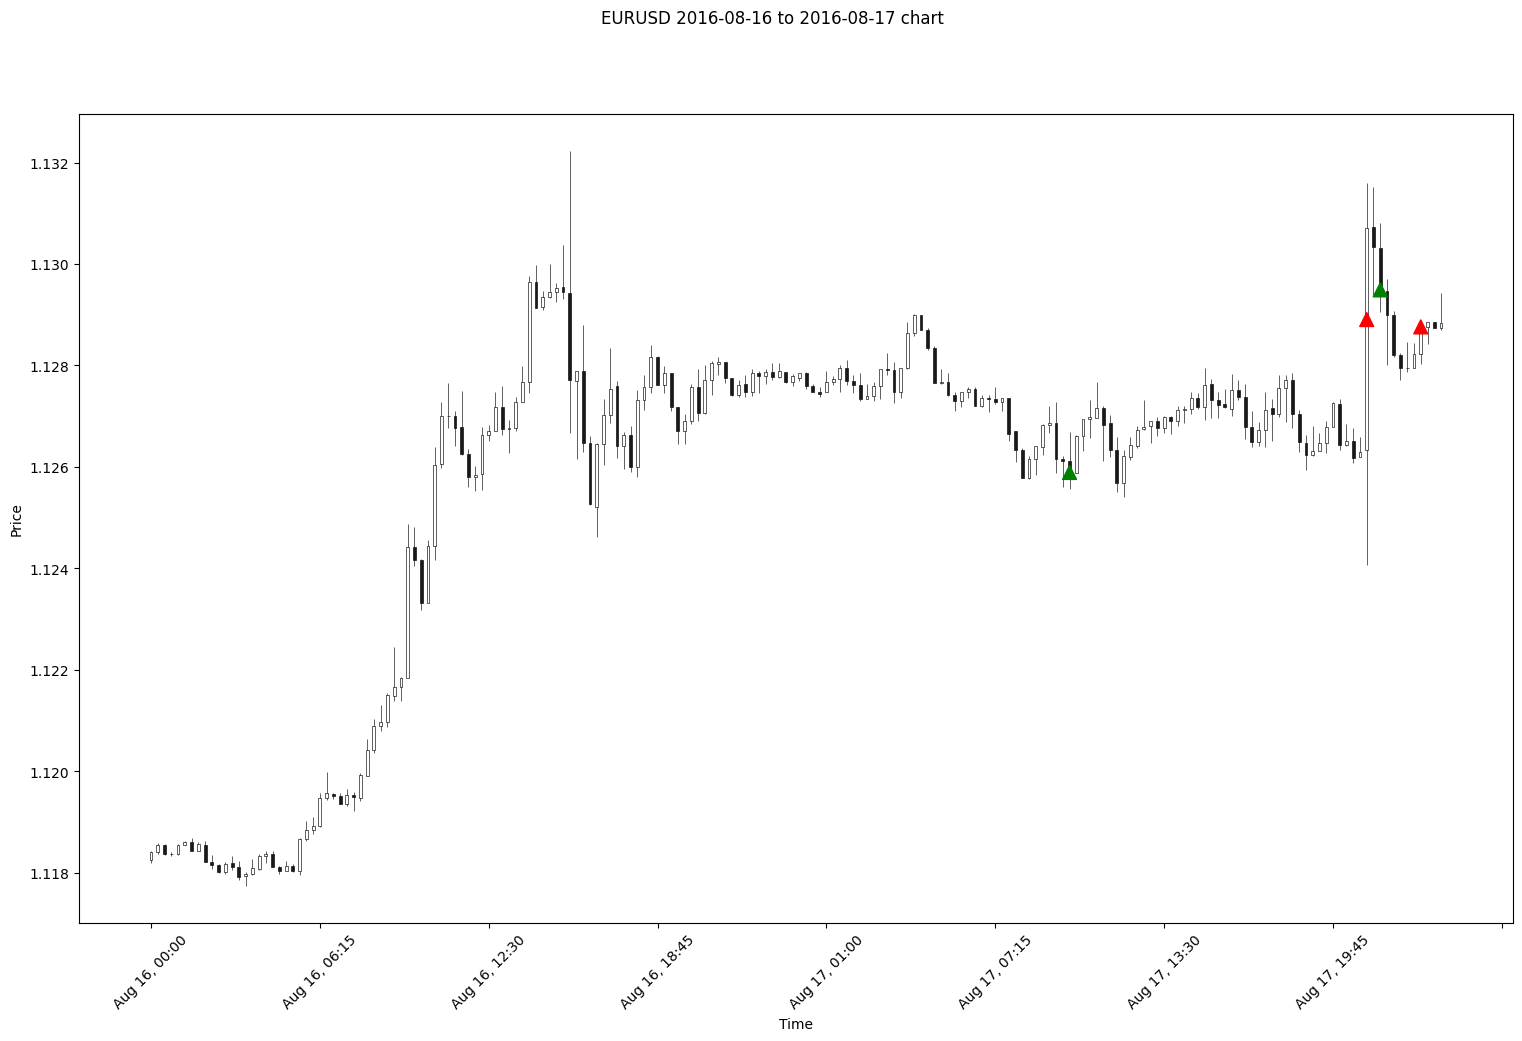

In [20]:
import matplotlib.pyplot as plt
import mplfinance
# filter to where the date and time is between 2024-03-07 16:36:00 and 2024.03.08 12:30:00
full_data_select_day = full_data_w_strategy_news[(full_data_w_strategy_news['Time'].dt.date >= datetime(2016, 8, 16).date()) & 
                                                       (full_data_w_strategy_news['Time'].dt.date <= datetime(2016, 8, 17).date())].set_index('Time')



fig, ax = plt.subplots()
mplfinance.plot(full_data_select_day, type='candle', ax=ax, volume=False, show_nontrading=False)
full_data_select_day_reset = full_data_select_day.reset_index()

if len(long_orders) > 0:
    # merge with long_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(long_orders, how='left', on='Time')
elif len(short_orders) > 0:
    # merge with short_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(short_orders, how='left', on='Time')
# Define color mapping
color_map = {'Entry': 'g', 'Exit': 'r'}
colors = full_data_select_day_reset['Entry/Exit'].fillna('Skip').map(color_map)

# Plot only non-NaN points
mask = full_data_select_day_reset['Entry/Exit'].notna()
ax.scatter(full_data_select_day_reset.index[mask], 
          full_data_select_day_reset['Entry/Exit Price'][mask], 
          c=colors[mask],
          s=100,
          marker='^',
          zorder=5)

# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
# ax.axhline(y=1.148443, color='g', linestyle='--')
# ax.axhline(y=1.112705, color='r', linestyle='--')
# ax.axhline(y=1.118060, color='r', linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
# find the date of the first and last index
first_date = full_data_select_day_reset['Time'].iloc[0]
last_date = full_data_select_day_reset['Time'].iloc[-1]
fig.suptitle(f'EURUSD {first_date.date()} to {last_date.date()} chart')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)

plt.show()

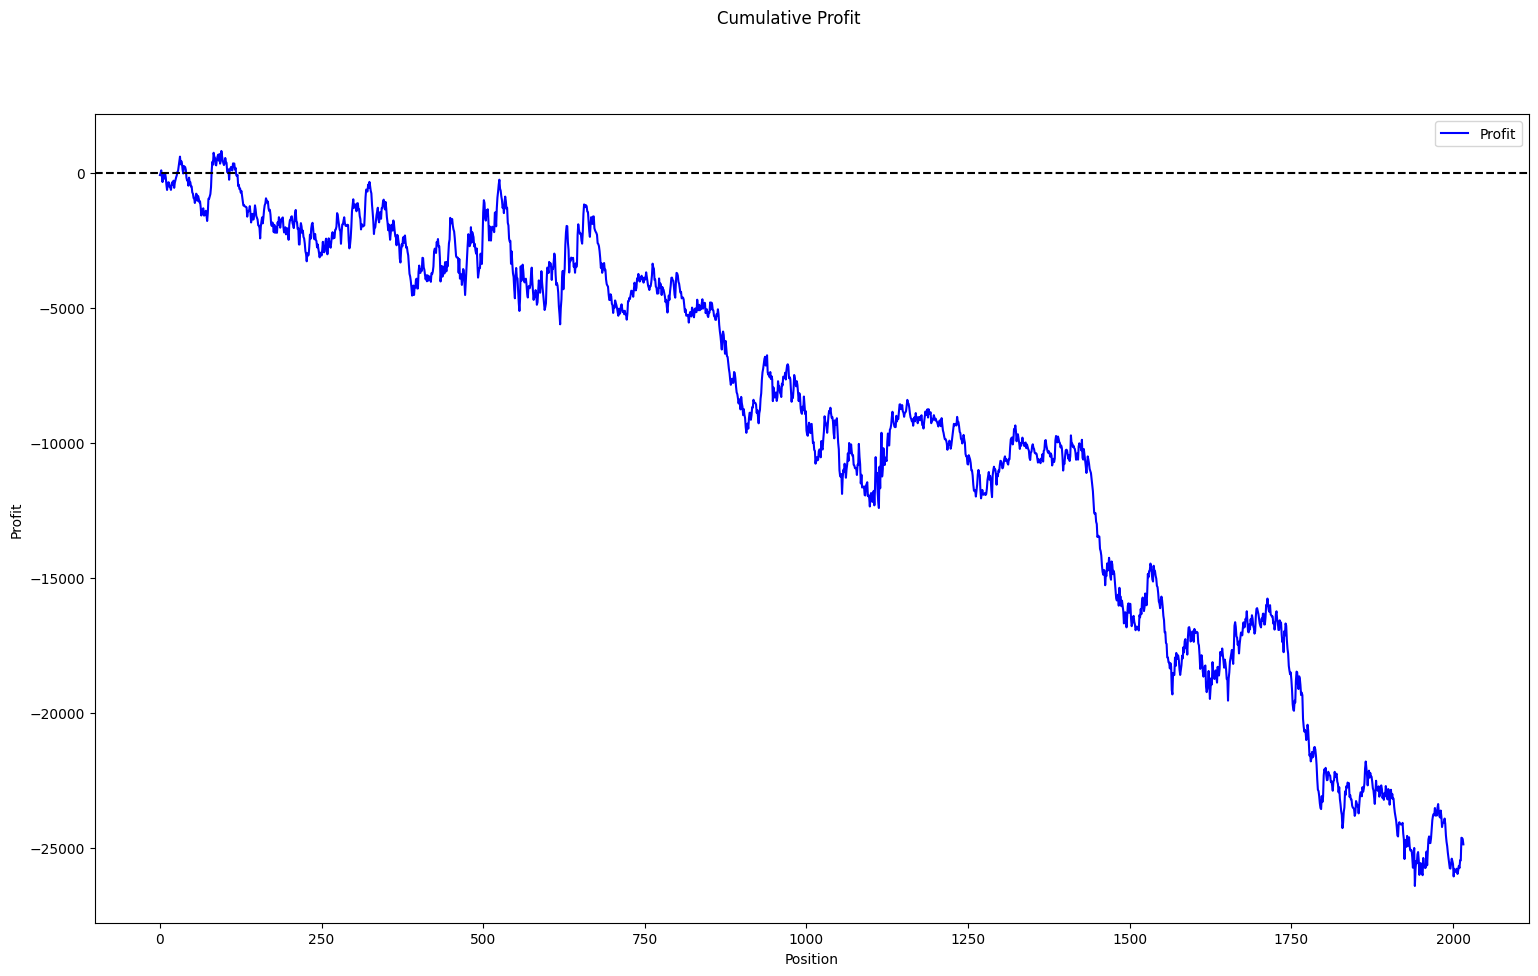

In [21]:
p_orders['cum_sum'] = p_orders['Profit'].cumsum()
# graph nova_profit_dollars and msolutions_profit_dollars over cum_position_count
fig, ax = plt.subplots()
ax.plot(p_orders['cum_sum'], label='Profit', color='blue')
# add in a line for 0 
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Position')
ax.set_ylabel('Profit')
fig.suptitle('Cumulative Profit')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)
# Add legend
ax.legend()
# Show the plot
plt.show()

In [22]:
p_orders[p_orders['Profit'] < 0]

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed,cum_sum
0,2017,EURUSD,Buy,1.0,2024-08-06 10:00:00+00:00,1.09362,2024-08-06 23:00:00+00:00,1.092990,375120.887781,379824.887781,-73.909931,1093.62,0.000109,True,-73.909931
3,2014,EURUSD,Sell,1.0,2024-07-31 10:00:00+00:00,1.08159,2024-07-31 14:00:00+00:00,1.083655,375019.081065,379852.081065,-216.656669,1081.59,0.000102,True,-114.849952
4,2013,EURUSD,Sell,1.0,2024-07-30 15:45:00+00:00,1.08019,2024-07-31 04:00:00+00:00,1.082225,375235.737734,379862.237734,-216.401140,1080.19,0.000129,True,-331.251092
6,2011,EURUSD,Sell,1.0,2024-07-30 10:15:00+00:00,1.08238,2024-07-30 11:30:00+00:00,1.083445,375177.434380,379879.434380,-119.479097,1082.38,0.000130,True,-176.025696
7,2010,EURUSD,Sell,1.0,2024-07-29 20:00:00+00:00,1.08246,2024-07-30 10:15:00+00:00,1.082635,375296.913477,379892.413477,-27.540608,1082.46,0.000100,True,-203.566304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010,7,EURUSD,Buy,1.0,2016-08-17 21:30:00+00:00,1.12949,2016-08-17 23:00:00+00:00,1.128760,400795.340552,399925.340552,-84.747517,1129.49,0.000117,True,-25759.200288
2012,5,EURUSD,Buy,1.0,2016-08-16 15:30:00+00:00,1.12771,2016-08-16 23:00:00+00:00,1.127780,400588.968804,399947.468804,-6.972902,1127.71,0.000140,True,-25475.053924
2014,3,EURUSD,Buy,1.0,2016-08-15 20:00:00+00:00,1.11840,2016-08-15 23:00:00+00:00,1.118400,399755.709013,399970.209013,-9.415373,1118.40,0.000094,True,-24644.236604
2015,2,EURUSD,Buy,1.0,2016-08-11 10:15:00+00:00,1.11420,2016-08-11 23:00:00+00:00,1.113930,399765.124385,399979.624385,-40.938273,1114.20,0.000139,True,-24685.174877


In [23]:
len(p_orders[p_orders['Profit'] > 0]) / len(p_orders)

0.4283589489340605

# Optimization

In [ ]:
from hyperopt import hp

search_space = {
    'high_timeframe': '4H',  # Fixed value since it's a string - '4H', '1H'
    'trend_window': hp.quniform('trend_window', 3, 10, 1),
    'sma_window': hp.quniform('sma_window', 3, 50, 1),
    'adx_length': hp.quniform('adx_length', 7, 21, 1),
    'adx_di': hp.quniform('adx_di', 7, 21, 1),
    'stop_loss_mult': hp.quniform('stop_loss_mult', 0.1, 3.5, 0.1),
    'take_profit_mult': hp.quniform('take_profit_mult', 0.1, 3.5, 0.1),
}



In [28]:
trials = Trials()
best = fmin(fn=objective,
            space=search_space,
            algo=tpe.suggest,
            max_evals=200, # Number of evaluations of the objective function
            trials=trials,
            trials_save_file=(
                f'{path_to_trading_folder}Indicator_backtesting/Indicator_search/trials_sma_trailing_sl_no_forward_data_1Ht_4HT_'
                f'{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl')
)
print("Best parameters:", best)

balance: 343,332.67, Expectancy: 12.498308166326112, profit: -56,667.33, total orders: 4,534, both_hit: 13
balance: 204,218.90, Expectancy: 8.793617535024168, profit: -195,781.10, total orders: 22,264, both_hit: 32
balance: 380,957.71, Expectancy: 9.825742995553782, profit: -19,042.29, total orders: 1,938, both_hit: 3
balance: 357,309.31, Expectancy: 14.560263583081209, profit: -42,690.69, total orders: 2,932, both_hit: 4
balance: 377,807.49, Expectancy: 12.68868331566938, profit: -22,192.51, total orders: 1,749, both_hit: 0
balance: 374,588.43, Expectancy: 12.763220851289375, profit: -25,411.57, total orders: 1,991, both_hit: 1
balance: 345,998.88, Expectancy: 16.960149200596447, profit: -54,001.12, total orders: 3,184, both_hit: 9
balance: 369,041.82, Expectancy: 14.777174995991743, profit: -30,958.18, total orders: 2,095, both_hit: 1
balance: 386,753.62, Expectancy: 23.362217849043574, profit: -13,246.38, total orders: 567, both_hit: 0
balance: 363,982.42, Expectancy: 17.41662508255

In [29]:
trials_latest_week = pickle.load(
    open(f'{path_to_trading_folder}Indicator_backtesting/Indicator_search/trials_sma_trailing_sl_no_forward_data_1Ht_4HT_20241210_052810.pkl', 'rb'))
trials_latest_week_all_results = trials_latest_week.results
# print(len(trials_latest_week_all_results),
# trials_latest_week_all_results[0])
best_hyperparameters_current_week = pd.DataFrame()
new_dict = {}

for idx, result in enumerate(trials_latest_week_all_results):
    new_dict['loss'] = result['loss']
    new_dict['status'] = result['status']
    new_dict['high_timeframe'] = result['parameters']['high_timeframe']
    new_dict['trend_window'] = result['parameters']['trend_window']
    new_dict['sma_window'] = result['parameters']['sma_window']
    new_dict['adx_length'] = result['parameters']['adx_length']
    new_dict['adx_di'] = result['parameters']['adx_di']
    new_dict['stop_loss_mult'] = result['parameters']['stop_loss_mult']
    new_dict['take_profit_mult'] = result['parameters']['take_profit_mult']

    new_row = pd.DataFrame(new_dict, index=[idx])
    best_hyperparameters_current_week = pd.concat([best_hyperparameters_current_week, new_row], axis=0)

best_hyperparameters_current_week



,loss,status,high_timeframe,trend_window,sma_window,adx_length,adx_di,stop_loss_mult,take_profit_mult
0,12.498308,ok,4H,2.0,40.0,11.0,13.0,0.6,1.6
1,8.793618,ok,4H,3.0,18.0,13.0,18.0,0.1,1.6
2,9.825743,ok,4H,5.0,18.0,10.0,15.0,1.2,1.6
3,14.560264,ok,4H,1.0,33.0,20.0,13.0,0.9,2.8
4,12.688683,ok,4H,2.0,30.0,7.0,18.0,2.4,3.3
...,...,...,...,...,...,...,...,...,...
195,10.389860,ok,4H,5.0,18.0,19.0,10.0,2.9,2.0
196,12.014243,ok,4H,4.0,10.0,16.0,9.0,1.9,2.7
197,11.539340,ok,4H,5.0,24.0,20.0,11.0,3.0,1.8
198,17.872480,ok,4H,5.0,48.0,17.0,8.0,2.0,2.9


In [30]:
positive = best_hyperparameters_current_week[best_hyperparameters_current_week['loss'] < 0].copy()
positive = positive.drop(columns=['status'])
positive['loss'] = positive['loss'] * -1

# Optimization Report

In [ ]:


from ydata_profiling import ProfileReport

# Create a profile report for your dataframe
profile = ProfileReport(positive, title="Data Profiling Report")

# Generate the report
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
positive.sort_values(by='loss', ascending=False).head(10)

,loss,high_timeframe,trend_window,sma_window,adx_length,adx_di,stop_loss_mult,take_profit_mult
1416,121.792077,4H,1.0,9.0,16,11,2.5,inf
841,121.752478,4H,1.0,9.0,16,11,2.5,inf
1361,121.752110,4H,1.0,9.0,16,11,2.5,inf
261,121.749524,4H,1.0,9.0,16,11,2.5,inf
1042,121.747807,4H,1.0,9.0,16,11,2.5,inf
830,121.746963,4H,1.0,9.0,16,11,2.5,inf
959,121.729196,4H,1.0,9.0,16,11,2.5,inf
1084,121.722366,4H,1.0,9.0,16,11,2.5,inf
657,121.720459,4H,1.0,9.0,16,11,2.5,inf
697,121.714365,4H,1.0,9.0,16,11,2.5,inf


In [ ]:
# p = positive.sort_values(by='loss', ascending=False).head(1).to_dict(orient='records')[0]
# p['stop_loss_mult'] = 3.5
# p['take_profit_mult'] = float('inf')
# objective(p)

balance: 583,426.14, Expectancy: -119.65175268455442, profit: 183,426.14, total orders: 1,533, both_hit: 0


{'loss': -119.65175268455442,
 'status': 'ok',
 'eval_time': datetime.datetime(2024, 12, 8, 6, 47, 49, 104698),
 'parameters': {'loss': 119.58179806852195,
  'high_timeframe': '4H',
  'trend_window': 1.0,
  'sma_window': 11.0,
  'adx_length': 17.0,
  'adx_di': 11.0,
  'stop_loss_mult': 3.5,
  'take_profit_mult': 3.5},
 'state':         Id  Symbol  Type  Volume                Entry Time  Entry Price  \
 0     1533  EURUSD  Sell     1.0 2024-08-07 10:00:00+00:00      1.09159   
 1     1532  EURUSD  Sell     1.0 2024-08-06 12:30:00+00:00      1.09129   
 2     1531  EURUSD   Buy     1.0 2024-08-05 10:00:00+00:00      1.09305   
 3     1530  EURUSD   Buy     1.0 2024-07-31 10:00:00+00:00      1.08159   
 4     1529  EURUSD  Sell     1.0 2024-07-30 10:00:00+00:00      1.08251   
 ...    ...     ...   ...     ...                       ...          ...   
 1528     5  EURUSD  Sell     1.0 2016-08-12 10:00:00+00:00      1.11462   
 1529     4  EURUSD  Sell     1.0 2016-08-11 16:00:00+00:00    

# Best parameters found

In [23]:
p = positive.sort_values(by='loss', ascending=False).head(1).to_dict(orient='records')[0]
p_all = objective(p)
p_orders = p_all['state']
full_df = p_all['full_df']

balance: 584,437.95, Expectancy: -121.66091897988372, profit: 184,437.95, total orders: 1,516, both_hit: 0


In [35]:
sorted(full_df.columns)

['Time',
 'Week_Nbr',
 'adx',
 'adx_slope',
 'atr',
 'both_hit',
 'close',
 'consecutive_bars',
 'high',
 'highest_close',
 'highest_open',
 'low',
 'lowest_close',
 'lowest_open',
 'ohlc4',
 'open',
 'position_size',
 'profit_distance',
 'seconds_since_last_news_event',
 'seconds_to_next_news_event',
 'signal',
 'sma',
 'stop_distance',
 'stop_level',
 'stop_loss_hit',
 'take_profit_hit',
 'trend']

In [36]:
p_orders.loc[:, 'Week_Nbr'] = (
    p_orders['Entry Time'].dt.year.astype(str) + 
    p_orders['Entry Time'].dt.isocalendar().week.astype(str)
)
# group by week and calculate the average profit, the number of trades, and the number of profitable trades
p_orders.groupby('Week_Nbr').agg({'Profit': 'sum', 'Id': 'count'}).agg({'Profit': 'mean'})

Profit    441.239122
dtype: float64

In [37]:
p_orders

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed,cum_sum,Week_Nbr
0,1516,EURUSD,Buy,1.0,2024-08-09 20:00:00+00:00,1.09165,2024-08-09 23:00:00+00:00,1.09168,584437.953174,384982.453174,-4.518386,1091.65,0.000075,True,-4.518386,202432
1,1515,EURUSD,Sell,1.0,2024-08-07 10:00:00+00:00,1.09159,2024-08-07 20:00:00+00:00,1.09209,584442.471560,384989.971560,-60.597813,1091.59,0.000106,True,-65.116199,202432
2,1514,EURUSD,Sell,1.0,2024-08-06 20:00:00+00:00,1.09248,2024-08-07 00:00:00+00:00,1.09289,584503.069372,385000.569372,-51.817628,1092.48,0.000108,True,-116.933827,202432
3,1513,EURUSD,Sell,1.0,2024-08-06 12:30:00+00:00,1.09129,2024-08-06 16:00:00+00:00,1.09156,584554.887001,385011.387001,-38.975082,1091.29,0.000120,True,-155.908910,202432
4,1512,EURUSD,Buy,1.0,2024-08-05 10:00:00+00:00,1.09305,2024-08-05 23:00:00+00:00,1.09594,584593.862083,385023.362083,277.284407,1093.05,0.000117,True,121.375497,202432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,5,EURUSD,Buy,1.0,2016-08-17 10:00:00+00:00,1.12589,2016-08-17 12:00:00+00:00,1.12621,400601.921263,399959.921263,26.301317,1125.89,0.000057,True,183862.333228,201633
1512,4,EURUSD,Buy,1.0,2016-08-16 10:00:00+00:00,1.12332,2016-08-16 23:00:00+00:00,1.12778,400575.619946,399965.619946,441.831527,1123.32,0.000042,True,184304.164755,201633
1513,3,EURUSD,Buy,1.0,2016-08-10 10:00:00+00:00,1.11445,2016-08-10 23:00:00+00:00,1.11754,400133.788419,399969.788419,300.321751,1114.45,0.000087,True,184604.486505,201632
1514,2,EURUSD,Sell,1.0,2016-08-08 12:00:00+00:00,1.10925,2016-08-08 16:00:00+00:00,1.10835,399833.466668,399978.466668,79.194163,1109.25,0.000108,True,184683.680668,201632


In [42]:
p_orders['Exit Time'] = pd.to_datetime(p_orders['Exit Time'])
p_orders[(p_orders['Exit Time'].dt.time <= time(10,0,0)) & 
             (p_orders['Exit Time'].dt.time >= time(3,0,0))]

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed,cum_sum,Week_Nbr
21,1495,EURUSD,Sell,1.0,2024-06-26 20:00:00+00:00,1.06871,2024-06-27 04:45:00+00:00,1.068930,583090.999553,385194.499553,-34.288795,1068.71,0.000123,True,1312.664825,202426
23,1493,EURUSD,Sell,1.0,2024-06-20 12:00:00+00:00,1.07238,2024-06-21 09:00:00+00:00,1.071995,583005.541729,385213.041729,26.424123,1072.38,0.000121,True,1458.835567,202425
29,1487,EURUSD,Sell,1.0,2024-06-10 10:00:00+00:00,1.07529,2024-06-11 04:00:00+00:00,1.076330,583088.381520,385273.381520,-118.524186,1075.29,0.000145,True,1231.047468,202424
33,1483,EURUSD,Sell,1.0,2024-05-29 16:00:00+00:00,1.08388,2024-05-30 08:00:00+00:00,1.079330,583000.699997,385310.699997,445.306959,1083.88,0.000097,True,1882.560136,202422
37,1479,EURUSD,Sell,1.0,2024-05-23 20:00:00+00:00,1.08173,2024-05-24 08:00:00+00:00,1.080900,582493.020827,385345.020827,71.261762,1081.73,0.000117,True,2016.194108,202421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,42,EURUSD,Sell,1.0,2016-10-11 12:00:00+00:00,1.11133,2016-10-13 05:30:00+00:00,1.103405,403448.875165,399613.875165,787.488522,1111.33,0.000050,True,181776.566530,201641
1478,38,EURUSD,Sell,1.0,2016-10-06 10:00:00+00:00,1.11991,2016-10-07 04:00:00+00:00,1.113430,402578.621681,399642.121681,639.110913,1119.91,0.000089,True,182498.442405,201640
1489,27,EURUSD,Sell,1.0,2016-09-20 20:00:00+00:00,1.11663,2016-09-21 04:00:00+00:00,1.114970,402758.625138,399743.625138,158.945241,1116.63,0.000071,True,181838.273277,201638
1503,13,EURUSD,Sell,1.0,2016-08-30 10:00:00+00:00,1.11742,2016-08-31 04:00:00+00:00,1.114760,401582.481947,399887.481947,258.193243,1117.42,0.000078,True,183113.664470,201635


In [53]:
full_df['Time'] = pd.to_datetime(full_df['Time'])
exit_df = full_df[full_df['Time'].dt.date == datetime(2024, 5, 24).date()]
exit_df

,Time,open,high,low,close,ohlc4,sma,lowest_close,lowest_open,highest_open,...,consecutive_bars,stop_distance,profit_distance,stop_level,seconds_since_last_news_event,seconds_to_next_news_event,Week_Nbr,take_profit_hit,stop_loss_hit,both_hit
194961,2024-05-24 00:00:00+00:00,1.08145,1.08150,1.08106,1.08132,1.081177,1.082886,1.08101,1.08145,1.08145,...,16,0.002750,inf,1.084070,-26100.0,401400.0,202421,0,0.0,0
194962,2024-05-24 00:15:00+00:00,1.08131,1.08147,1.08110,1.08124,1.081177,1.082886,1.08101,1.08145,1.08145,...,17,0.002750,inf,1.083990,-27000.0,400500.0,202421,0,0.0,0
194963,2024-05-24 00:30:00+00:00,1.08127,1.08149,1.08126,1.08131,1.081177,1.082886,1.08101,1.08145,1.08145,...,18,0.002750,inf,1.083990,-27900.0,399600.0,202421,0,0.0,0
194964,2024-05-24 00:45:00+00:00,1.08131,1.08148,1.08125,1.08146,1.081177,1.082886,1.08101,1.08145,1.08145,...,19,0.002750,inf,1.083990,-28800.0,398700.0,202421,0,0.0,0
194965,2024-05-24 01:00:00+00:00,1.08145,1.08149,1.08124,1.08126,1.081177,1.082886,1.08101,1.08145,1.08145,...,20,0.002750,inf,1.083990,-29700.0,397800.0,202421,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195052,2024-05-24 22:45:00+00:00,1.08485,1.08497,1.08480,1.08488,1.084762,1.083009,1.08460,1.08470,1.08470,...,27,0.002675,inf,1.082205,-108000.0,319500.0,202421,0,0.0,0
195053,2024-05-24 23:00:00+00:00,1.08488,1.08492,1.08482,1.08484,1.084762,1.083009,1.08460,1.08470,1.08470,...,28,0.001850,inf,1.082990,-108900.0,318600.0,202421,0,0.0,0
195054,2024-05-24 23:15:00+00:00,1.08484,1.08485,1.08466,1.08473,1.084762,1.083009,1.08460,1.08470,1.08470,...,29,0.001850,inf,1.082880,-109800.0,317700.0,202421,0,0.0,0
195055,2024-05-24 23:30:00+00:00,1.08474,1.08483,1.08468,1.08475,1.084762,1.083009,1.08460,1.08470,1.08470,...,30,0.001675,inf,1.083075,-110700.0,316800.0,202421,0,0.0,0


In [25]:
# calculate the win rate:
win_rate = len(p_orders[p_orders['Profit'] > 0]) / len(p_orders)
win_rate

0.6292875989445911

In [54]:
p_orders_select_day = p_orders.loc[(p_orders['Entry Time'].dt.date >= datetime(2024, 5, 23).date()) &
                                   (p_orders['Entry Time'].dt.date <= datetime(2024, 5, 24).date()),
                                     ['Entry Time', 'Exit Time', 'Entry Price', 'Exit Price', 'Type']].copy()
# Create entry rows
entries = p_orders_select_day[['Type', 'Entry Time', 'Entry Price']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
# Create exit rows 
exits = p_orders_select_day[['Type', 'Exit Time', 'Exit Price']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'

# Combine and sort by time
p_orders_select_day = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Buy'].copy()
short_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Long Entry/Exit Price',
                                          'Entry/Exit': 'Long Entry/Exit'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Short Entry/Exit Price',
                                            'Entry/Exit': 'Short Entry/Exit'}).drop(columns=['Type'])
long_orders

,Time,Long Entry/Exit Price,Long Entry/Exit
1,2024-05-23 12:00:00+00:00,1.08366,Entry
3,2024-05-23 16:00:00+00:00,1.08592,Exit
6,2024-05-24 16:00:00+00:00,1.08499,Entry
7,2024-05-24 23:00:00+00:00,1.08484,Exit


In [55]:
short_orders

,Time,Short Entry/Exit Price,Short Entry/Exit
0,2024-05-23 11:30:00+00:00,1.08411,Entry
2,2024-05-23 12:00:00+00:00,1.08366,Exit
4,2024-05-23 20:00:00+00:00,1.08173,Entry
5,2024-05-24 08:00:00+00:00,1.08090,Exit


In [51]:
full_df.loc[(full_df['stop_loss_hit'] != 0), ['Time', 'open', 'high', 'low', 'close']]

,Time,open,high,low,close
4479,2016-10-04 18:30:00+00:00,1.11532,1.12150,1.11531,1.11924
5099,2016-10-13 05:30:00+00:00,1.10223,1.10358,1.10218,1.10295
8001,2016-11-24 11:00:00+00:00,1.05543,1.05764,1.05516,1.05718
9525,2016-12-16 08:00:00+00:00,1.04333,1.04437,1.04333,1.04426
10672,2017-01-03 06:45:00+00:00,1.04863,1.04898,1.04857,1.04882
...,...,...,...,...,...
193491,2024-05-02 16:30:00+00:00,1.06944,1.06981,1.06829,1.06878
194909,2024-05-23 11:00:00+00:00,1.08290,1.08417,1.08282,1.08416
196917,2024-06-21 09:00:00+00:00,1.07178,1.07205,1.07164,1.07198
197284,2024-06-27 04:45:00+00:00,1.06843,1.06895,1.06843,1.06886


In [66]:
four_am = full_df[(full_df['Time'] >= datetime(2016, 8, 1, 4, 0, 0, tzinfo=pytz.utc)) &
        (full_df['Time'] < datetime(2016, 8, 1, 8, 0, 0, tzinfo=pytz.utc))]
print(four_am['open'].iloc[0],
four_am['close'].iloc[-1],
four_am['low'].min(),
four_am['high'].max())

1.1175 1.11794 1.11662 1.11814


In [61]:
full_df.set_index('Time').resample('4H').agg({
            'open': 'first', 
            'high': 'max', 
            'low': 'min', 
            'close': 'last'
        })

,open,high,low,close
Time,,,,
2016-08-01 00:00:00+00:00,1.11672,1.11767,1.11660,1.11750
2016-08-01 04:00:00+00:00,1.11750,1.11814,1.11662,1.11794
2016-08-01 08:00:00+00:00,1.11793,1.11806,1.11596,1.11596
2016-08-01 12:00:00+00:00,1.11596,1.11774,1.11552,1.11649
2016-08-01 16:00:00+00:00,1.11649,1.11791,1.11602,1.11709
...,...,...,...,...
2024-08-09 04:00:00+00:00,1.09131,1.09243,1.09119,1.09201
2024-08-09 08:00:00+00:00,1.09201,1.09290,1.09129,1.09175
2024-08-09 12:00:00+00:00,1.09176,1.09257,1.09090,1.09117


In [29]:
full_df['trend'].value_counts()

trend
-1.0    83280
 1.0    79985
 0.0    37068
Name: count, dtype: int64

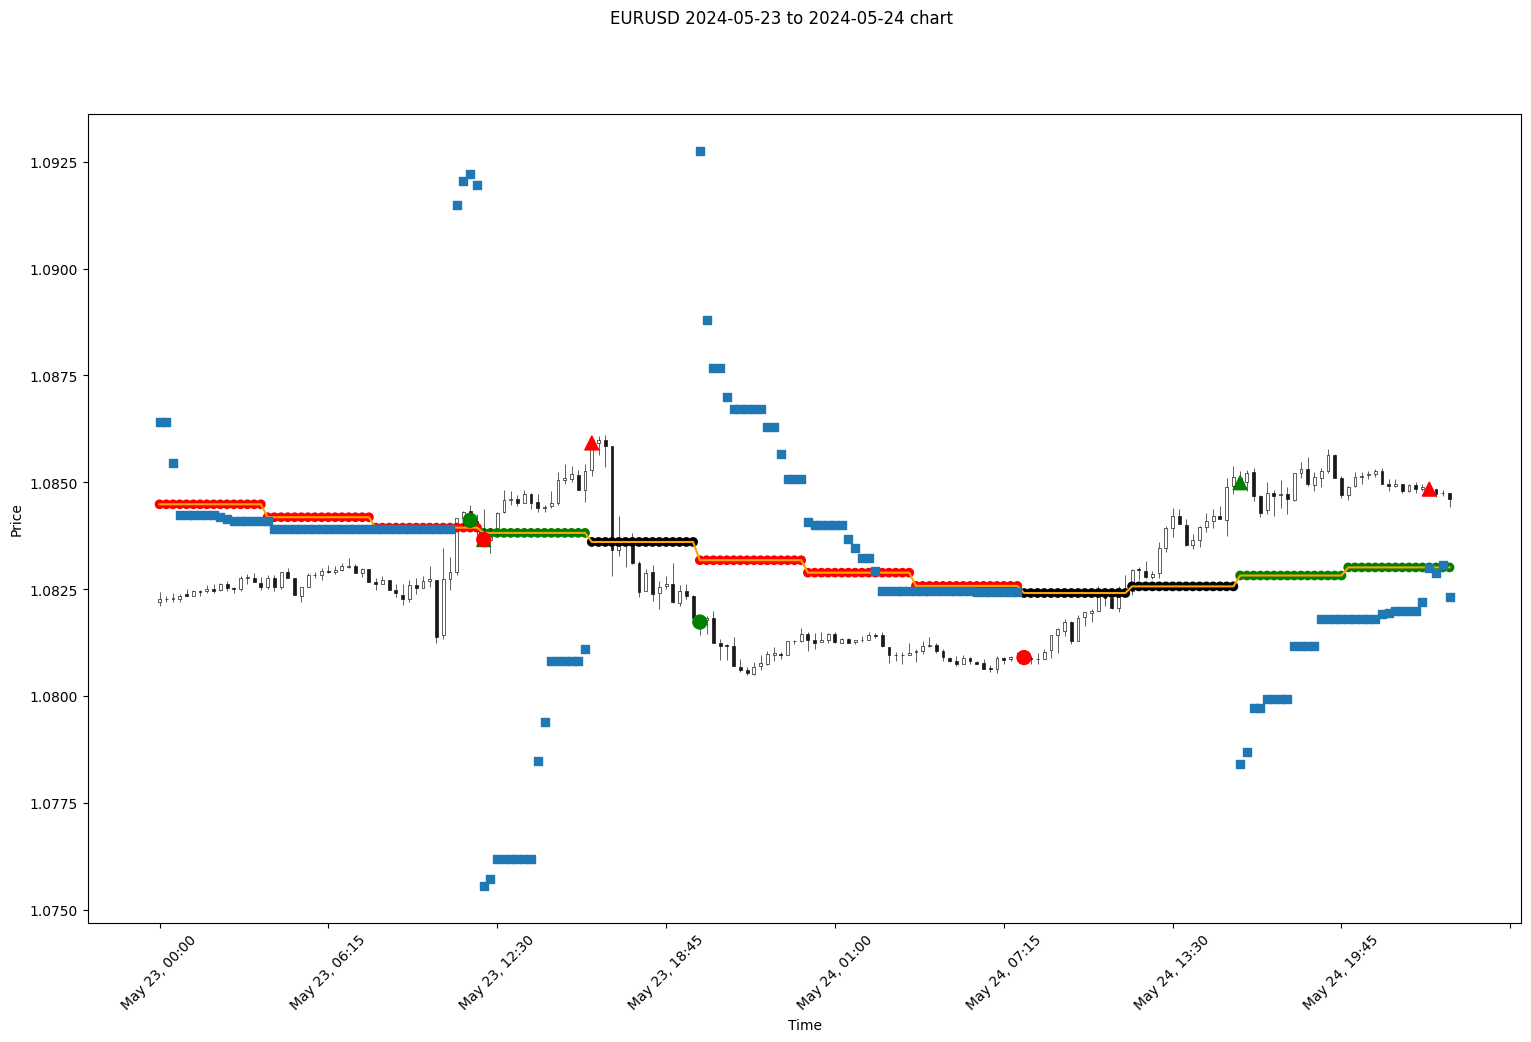

In [57]:
import matplotlib.pyplot as plt
%matplotlib inline
import mplfinance
# filter to where the date and time is between 2024-03-07 16:36:00 and 2024.03.08 12:30:00
full_data_select_day = full_df[(full_df['Time'].dt.date >= datetime(2024, 5, 23).date()) & 
                                                       (full_df['Time'].dt.date <= datetime(2024, 5, 24).date())].set_index('Time')



fig, ax = plt.subplots()
mplfinance.plot(full_data_select_day, type='candle', ax=ax, volume=False, show_nontrading=False)
full_data_select_day_reset = full_data_select_day.reset_index()

if len(long_orders) > 0:
    # merge with long_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(long_orders, how='left', on='Time')
    # Define color mapping
    color_map = {'Entry': 'g', 'Exit': 'r'}
    colors = full_data_select_day_reset['Long Entry/Exit'].fillna('Skip').map(color_map)

    # Plot only non-NaN points
    mask = full_data_select_day_reset['Long Entry/Exit'].notna()
    ax.scatter(full_data_select_day_reset.index[mask], 
            full_data_select_day_reset['Long Entry/Exit Price'][mask], 
            c=colors[mask],
            s=100,
            marker='^', zorder=5) #, zorder=5
if len(short_orders) > 0:
    # merge with short_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(short_orders, how='left', on='Time')
    # Define color mapping
    color_map = {'Entry': 'g', 'Exit': 'r'}
    colors = full_data_select_day_reset['Short Entry/Exit'].fillna('Skip').map(color_map)

    # Plot only non-NaN points
    mask = full_data_select_day_reset['Short Entry/Exit'].notna()
    ax.scatter(full_data_select_day_reset.index[mask], 
            full_data_select_day_reset['Short Entry/Exit Price'][mask], 
            c=colors[mask],
            s=100,
            marker='o', zorder=6) #, zorder=5
ax.scatter(full_data_select_day_reset.index, 
        full_data_select_day_reset['stop_level'], 
        s=30,
        marker='s', zorder=7)
# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
ax.plot(full_data_select_day_reset.index, full_data_select_day_reset['sma'], color='orange', label='SMA')
# Create color mapping
color_map = {1: 'green', 0: 'black', -1: 'red'}
colors = full_data_select_day_reset['trend'].map(color_map)

# Plot with mapped colors
ax.scatter(full_data_select_day_reset.index, full_data_select_day_reset['sma'], color=colors)
# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
# ax.axhline(y=1.148443, color='g', linestyle='--')
# ax.axhline(y=1.11438, color='r', linestyle='--')
# ax.axhline(y=1.118060, color='r', linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
# find the date of the first and last index
first_date = full_data_select_day_reset['Time'].iloc[0]
last_date = full_data_select_day_reset['Time'].iloc[-1]
fig.suptitle(f'EURUSD {first_date.date()} to {last_date.date()} chart')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)

plt.show()

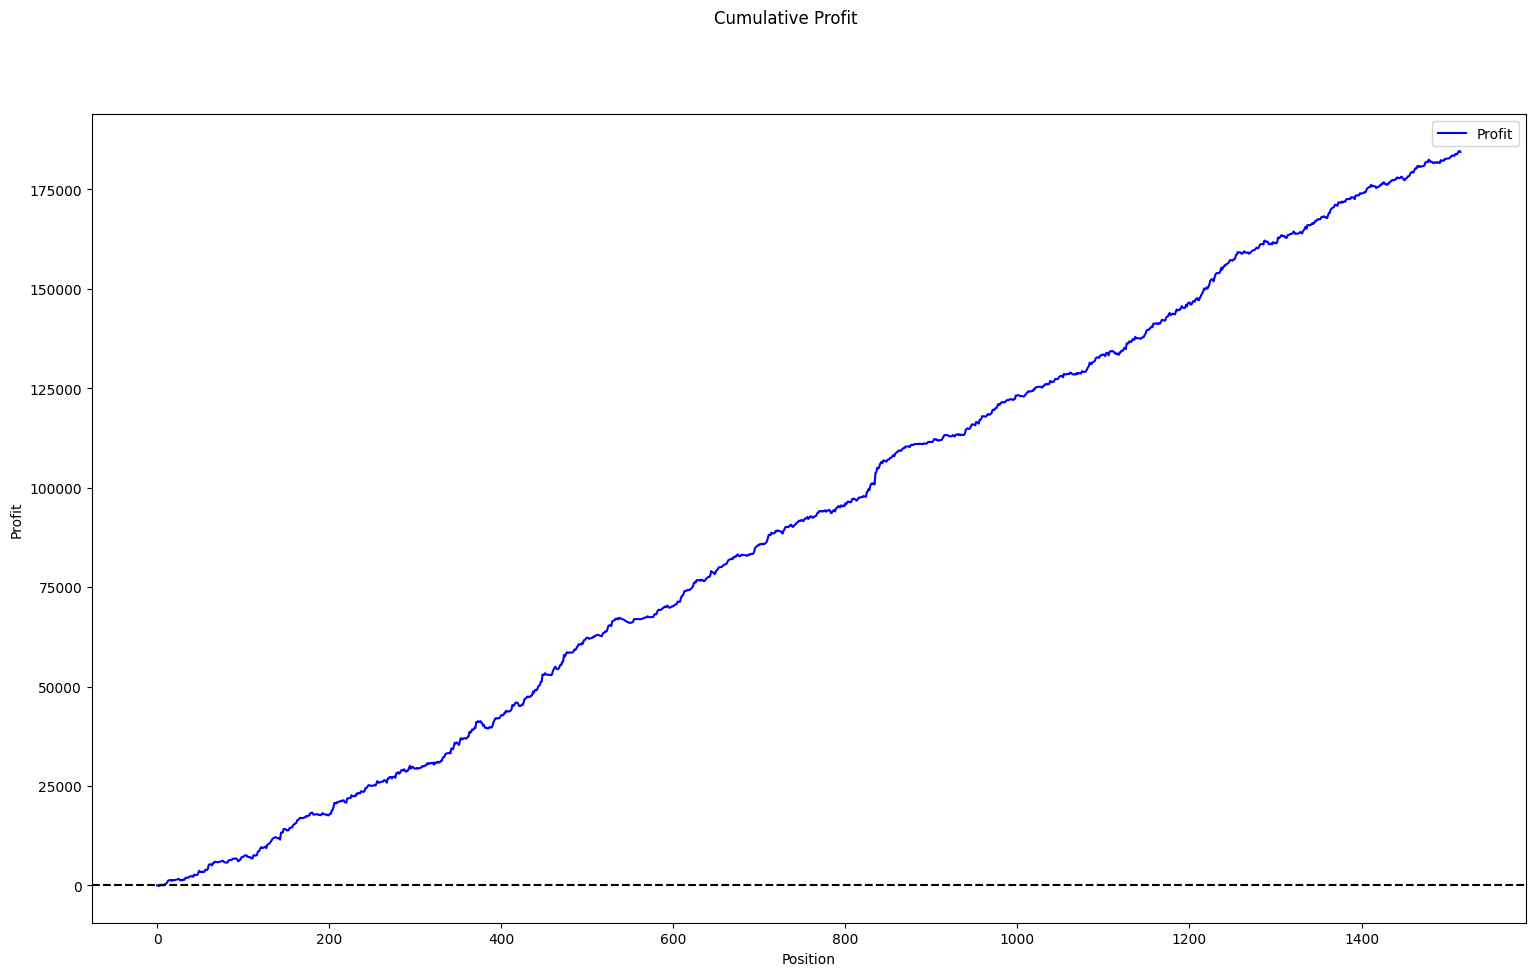

In [31]:
p_orders['cum_sum'] = p_orders['Profit'].cumsum()
# graph nova_profit_dollars and msolutions_profit_dollars over cum_position_count
fig, ax = plt.subplots()
ax.plot(p_orders['cum_sum'], label='Profit', color='blue')
# add in a line for 0 
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Position')
ax.set_ylabel('Profit')
fig.suptitle('Cumulative Profit')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)
# Add legend
ax.legend()
# Show the plot
plt.show()

In [32]:
# Create entry rows
entries = p_orders[['Type', 'Entry Time', 'Entry Price', 'Profit']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
entries['Profitable'] = entries['Profit'] > 0
entries.drop(columns=['Profit'], inplace=True)
# Create exit rows 
exits = p_orders[['Type', 'Exit Time', 'Exit Price', 'Profit']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'
exits['Profitable'] = exits['Profit'] > 0
exits.drop(columns=['Profit'], inplace=True)


# Combine and sort by time
p_orders_entry_exits = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_entry_exits[p_orders_entry_exits['Type'] == 'Buy'].copy()
short_orders = p_orders_entry_exits[p_orders_entry_exits['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Long Entry/Exit Price',
                                          'Entry/Exit': 'Long Entry/Exit',
                                          'Profitable': 'Long Profitable'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Short Entry/Exit Price',
                                            'Entry/Exit': 'Short Entry/Exit',
                                            'Profitable': 'Short Profitable'}).drop(columns=['Type'])
full_df_w_long_order_entry_exits = full_df.merge(long_orders, how='left', on='Time')
full_df_w_l_s_order_entry_exits = full_df_w_long_order_entry_exits.merge(short_orders, how='left', on='Time')
print(full_df_w_l_s_order_entry_exits.loc[(full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry') &
        (full_df_w_l_s_order_entry_exits['Long Profitable'] == True), 'consecutive_bars'].mean(),
full_df_w_l_s_order_entry_exits.loc[(full_df_w_l_s_order_entry_exits['Short Entry/Exit'] == 'Entry') &
        (full_df_w_l_s_order_entry_exits['Short Profitable'] == True), 'consecutive_bars'].mean(),
full_df_w_l_s_order_entry_exits.loc[(full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry') &
        (full_df_w_l_s_order_entry_exits['Long Profitable'] == False), 'consecutive_bars'].mean(),
full_df_w_l_s_order_entry_exits.loc[(full_df_w_l_s_order_entry_exits['Short Entry/Exit'] == 'Entry') &
        (full_df_w_l_s_order_entry_exits['Short Profitable'] == False), 'consecutive_bars'].mean())


27.749498997995993 20.87032967032967 33.064516129032256 17.333333333333332


In [33]:
# Profitable Long trades consecutive bars
profitable_long = full_df_w_l_s_order_entry_exits.loc[
    (full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry') &
    (full_df_w_l_s_order_entry_exits['Long Profitable'] == True), 
    'consecutive_bars'
]

# Profitable Short trades consecutive bars
profitable_short = full_df_w_l_s_order_entry_exits.loc[
    (full_df_w_l_s_order_entry_exits['Short Entry/Exit'] == 'Entry') &
    (full_df_w_l_s_order_entry_exits['Short Profitable'] == True), 
    'consecutive_bars'
]

# Unprofitable Long trades consecutive bars
unprofitable_long = full_df_w_l_s_order_entry_exits.loc[
    (full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry') &
    (full_df_w_l_s_order_entry_exits['Long Profitable'] == False), 
    'consecutive_bars'
]

# Unprofitable Short trades consecutive bars
unprofitable_short = full_df_w_l_s_order_entry_exits.loc[
    (full_df_w_l_s_order_entry_exits['Short Entry/Exit'] == 'Entry') &
    (full_df_w_l_s_order_entry_exits['Short Profitable'] == False), 
    'consecutive_bars'
]


In [34]:
from scipy import stats

# 1. Perform Mann-Whitney U tests
# Profitable Long vs Short
stat_profitable, p_profitable = stats.mannwhitneyu(
    profitable_long, 
    profitable_short,
    alternative='two-sided'
)

# Unprofitable Long vs Short 
stat_unprofitable, p_unprofitable = stats.mannwhitneyu(
    unprofitable_long,
    unprofitable_short,
    alternative='two-sided'
)

# Long Profitable vs Unprofitable
stat_long, p_long = stats.mannwhitneyu(
    profitable_long,
    unprofitable_long,
    alternative='two-sided'
)

# Short Profitable vs Unprofitable
stat_short, p_short = stats.mannwhitneyu(
    profitable_short,
    unprofitable_short,
    alternative='two-sided'
)

# 2. Print results
print("Mann-Whitney U Test Results:")
print(f"\nProfitable Long vs Short: p={p_profitable:.4f}")
print(f"Unprofitable Long vs Short: p={p_unprofitable:.4f}")
print(f"Long Profitable vs Unprofitable: p={p_long:.4f}")
print(f"Short Profitable vs Unprofitable: p={p_short:.4f}")


Mann-Whitney U Test Results:

Profitable Long vs Short: p=0.0334
Unprofitable Long vs Short: p=0.0001
Long Profitable vs Unprofitable: p=0.0624
Short Profitable vs Unprofitable: p=0.4155


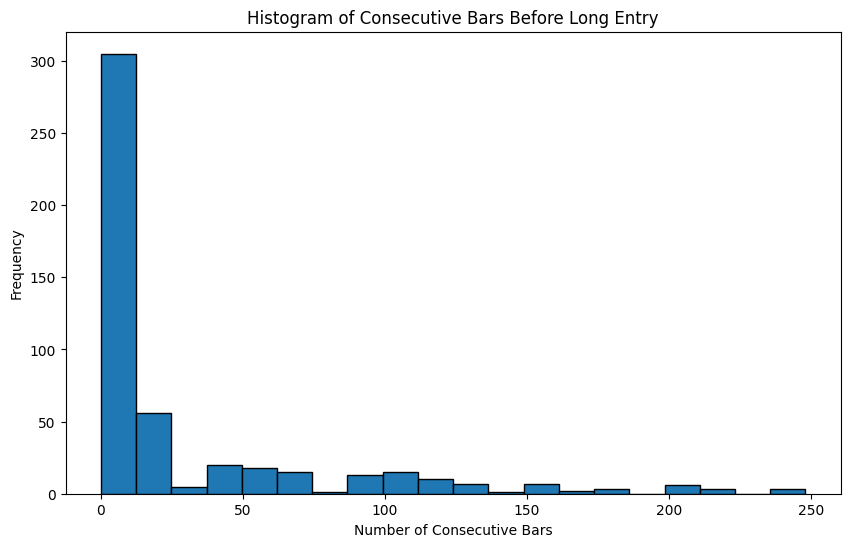

In [103]:
# plot the histogram of full_df_w_l_s_order_entry_exits.loc[full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry', 'consecutive_bars']
import matplotlib.pyplot as plt

# 1. Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(
    full_df_w_l_s_order_entry_exits.loc[
        (full_df_w_l_s_order_entry_exits['Long Entry/Exit'] == 'Entry') &
        (full_df_w_l_s_order_entry_exits['Long Profitable'] == True), 
        'consecutive_bars'
    ],
    bins=20,
    edgecolor='black'
)

# 2. Add labels and title
plt.xlabel('Number of Consecutive Bars')
plt.ylabel('Frequency')
plt.title('Histogram of Consecutive Bars Before Long Entry')

# 3. Display the plot
plt.show()
